# Day 2 上午：预训练与 SFT（~3h）

## 学习目标

1. 体验从零预训练（Pretraining）的完整流程
2. 理解 Base Model → Chat Model 的完整链路
3. 完成 SFT（Supervised Fine-Tuning）全流程实操
4. 知道什么场景需要全量微调

### 时间安排

| 时间 | 内容 | 类型 |
|:---|:---|:---|
| 0:00-0:15 | LLM 生命周期：pretrain → SFT → align → deploy | 讲解 |
| 0:15-0:45 | 预训练 demo：在中文语料上训练 TinyLlama | 代码随讲 |
| 0:45-0:55 | 练习1：修改训练数据，观察输出质量变化 | 练习 |
| 0:55-1:10 | 练习2：分析 loss 曲线，诊断过拟合 | 练习 |
| 1:10-1:20 | 休息 | |
| 1:20-1:35 | SFT 动机：Base model 不会聊天 | 演示 |
| 1:35-1:50 | ChatML + Loss Masking | 代码随讲 |
| 1:50-2:00 | 练习3：实现 SFT loss masking | 练习 |
| 2:00-2:25 | SFT 训练实战 | 代码随讲 |
| 2:25-2:35 | 练习4：对比 base vs SFT 准确率 | 练习 |
| 2:35-2:50 | 练习5：调超参（lr, epochs）观察效果 | 练习 |
| 2:50-3:00 | Mini-project：展示 SFT 前后对比 | 演示 |

In [1]:
# ── 课程环境就位（自动定位课程根目录，让 utils/data/fonts 路径无论从 instructor/ 还是 student/ 都能用）──
import os, sys
_cur = os.path.abspath("")
_root = None
for _candidate in [_cur] + [os.path.dirname(_cur), os.path.dirname(os.path.dirname(_cur))]:
    if all(os.path.isdir(os.path.join(_candidate, d)) for d in ("utils", "data")):
        _root = _candidate
        break
if _root is None:
    raise RuntimeError("找不到课程根目录（应包含 utils/ 与 data/）。请确认 notebook 位于 enterprise_ver2/instructor 或 enterprise_ver2/student 下。")
os.chdir(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)
if os.path.join(_root, "utils") not in sys.path:
    sys.path.insert(0, os.path.join(_root, "utils"))
print(f"📂 课程根目录：{_root}")


📂 课程根目录：C:\Users\lvbab\Documents\GitHub\LLM-Agent-Core_Concept_Code\assets\enterprise_5days


In [2]:
# 关闭 HuggingFace 进度条和无关警告
import os, warnings
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
warnings.filterwarnings("ignore", message=".*tie_word_embeddings.*")
warnings.filterwarnings("ignore", message=".*UNEXPECTED.*")

import sys


In [3]:
# ── 中文字体 + 图表美化 ──
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager as fm

font_path = "fonts/NotoSansCJKsc-Regular.otf"
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

plt.rcParams["font.sans-serif"] = ["Noto Sans CJK SC", "Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

---
## Part 1：LLM 生命周期全景（0:00-0:15）

一个大语言模型从"出生"到"上岗"，要经过四个阶段：

| 阶段 | 做什么 | 数据 | 产出 | 企业通常从哪进入 |
|:---|:---|:---|:---|:---|
| **预训练（Pretraining）** | 在海量文本上学习语言规律 | TB 级无标注文本 | Base Model（只会续写） | 很少自己做 |
| **SFT（指令微调）** | 教模型遵循指令、按格式回答 | 万~十万条 instruction-response | Chat Model（能对话） | **最常见切入点** |
| **对齐（Alignment）** | 让输出更安全、更符合人类偏好 | 偏好对比数据 | Aligned Model | 高阶需求 |
| **部署（Deployment）** | 量化、缓存、API 化 | 无 | Production Service | 必须做 |

### 关键认知

- **预训练**给模型"知识"和"语言能力"，但它不知道怎么跟人对话
- **SFT**教模型"行为模式"——用 instruction-response 数据把能力激活为对话能力
- 企业落地最常见路径：拿开源 Base Model → SFT 适配业务场景
- 今天上午我们按正确顺序体验：**先预训练，再 SFT**

---
## Part 2：预训练 Demo（0:15-0:45）

> 从零训练一个能生成中文文本的小型语言模型。
>
> 体验完整流程：**数据准备 → 词表构建 → 模型定义 → 训练循环 → 文本生成**

### 2.1 环境与依赖

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import time
import math

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu128


### 2.2 准备数据：中文预训练语料

预训练的核心：给模型大量文本，让它学习"给定前文，预测下一个字"。

In [5]:
# 读取本地中文预训练语料
from pathlib import Path
from collections import Counter

def resolve_data_dir():
    candidates = [Path.cwd(), Path.cwd().parent]
    for base in candidates:
        data_dir = base / "data"
        if data_dir.exists():
            return str(data_dir)
    return os.path.join(os.getcwd(), "data")

DATA_DIR = resolve_data_dir()
PROJECT_ROOT = str(Path(DATA_DIR).parent)
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
os.makedirs(MODELS_DIR, exist_ok=True)
data_path = os.path.join(DATA_DIR, "pretrain_corpus_zh.txt")  # 6 MB 中文 wiki 子集（主 repo 同源）
if not os.path.exists(data_path):
    print(f"[INFO] {data_path} 不存在，回退 12 KB 演示语料")
    data_path = os.path.join(DATA_DIR, "custom_pretrain_corpus.txt")
BEST_MODEL_PATH = os.path.join(MODELS_DIR, "ch7_pretrain_best_model.pt")

if not os.path.exists(data_path):
    raise FileNotFoundError(f"未找到预训练语料: {data_path}")

with open(data_path, "r", encoding="utf-8") as f:
    text = f.read()

# 基本统计
num_lines = text.count('\n')
cjk_chars = [c for c in text if '\u4e00' <= c <= '\u9fff']

print(f"语料统计:")
print(f"  总字符数:   {len(text):>10,}")
print(f"  总行数:     {num_lines:>10,}")
print(f"  中文字符数: {len(cjk_chars):>10,}  ({len(cjk_chars)/len(text)*100:.1f}%)")
print(f"\n前300字符预览:")
print(text[:300])

语料统计:
  总字符数:    2,125,908
  总行数:         14,746
  中文字符数:  1,723,800  (81.1%)

前300字符预览:
数学，是研究數量、结构以及空间等概念及其变化的一門学科，屬於形式科學的一種。數學利用抽象化和邏輯推理，從計數、計算、量度、對物體形狀及運動的觀察發展而成。數學家們拓展這些概念，以公式化新的猜想，以及從選定的公理及定義出發，嚴謹地推導出一些定理。
基礎數學的知識與運用是生活中不可或缺的一環。對數學基本概念的完善，早在古埃及、美索不达米亚及古印度历史上的古代數學文本便可觀見，而在古希臘那裡有更為嚴謹的處理。從那時開始，數學的發展便持續不斷地小幅進展，至16世紀的文藝復興時期，因为新的科學發現和數學革新兩者的交互，致使數學的加速发展，直至今日。数学并成为許多國家及地區的教育中的一部分。
数学在许多领


In [6]:
# 构建字符级词表（Character-level Vocabulary）
chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

fallback_id = stoi.get(' ', stoi.get('\n', 0))
encode = lambda s: [stoi.get(c, fallback_id) for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

print(f"vocab_size: {vocab_size}")
test_str = text[:10]
encoded = encode(test_str)
decoded = decode(encoded)
print(f"\nEncode/Decode 测试:")
print(f"  原文:   {test_str}")
print(f"  编码:   {encoded}")
print(f"  解码:   {decoded}")

vocab_size: 7196



Encode/Decode 测试:
  原文:   数学，是研究數量、结
  编码:   [2548, 1593, 7164, 2630, 4096, 4280, 2553, 6219, 267, 4620]
  解码:   数学，是研究數量、结


### 2.3 创建 Dataset 和 DataLoader

预训练用**滑动窗口**从语料中构造 (input, target) 对：

```
原始文本: "深度学习是用多层..."    block_size=5

样本1: input=[深,度,学,习,是]  target=[度,学,习,是,用]
样本2: input=[度,学,习,是,用]  target=[学,习,是,用,多]
```

target 就是 input 右移一位——这就是 Next-Token Prediction。

In [7]:
class TextDataset(Dataset):
    """文本数据集：每个样本是 (input, target) 对，target 是 input 右移一位"""
    def __init__(self, text, block_size):
        self.data = torch.tensor(encode(text), dtype=torch.long)
        self.block_size = block_size

    def __len__(self):
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        x = self.data[idx:idx + self.block_size]
        y = self.data[idx + 1:idx + self.block_size + 1]
        return x, y

# 训练/验证集划分（90% / 10%）
n = int(0.9 * len(text))
train_text = text[:n]
val_text = text[n:]

block_size = 64   # 上下文长度
batch_size = 32

train_dataset = TextDataset(train_text, block_size)
val_dataset = TextDataset(val_text, block_size)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"训练集: {len(train_dataset):,} 个样本")
print(f"验证集: {len(val_dataset):,} 个样本")
print(f"每 batch: {batch_size} x {block_size} = {batch_size * block_size:,} tokens")

# 查看一个样本
x, y = next(iter(train_loader))
print(f"\nBatch shape: x={x.shape}, y={y.shape}")
print(f"输入: {decode(x[0].tolist())}")
print(f"目标: {decode(y[0].tolist())}")

训练集: 1,913,253 个样本


验证集: 212,527 个样本
每 batch: 32 x 64 = 2,048 tokens



Batch shape: x=torch.Size([32, 64]), y=torch.Size([32, 64])
输入: 天房集团、天津物产集团等多家天津市市属国有企业相继面临债务危机。2017年，受环保督查、全运会停工等多重因素叠加，天津市经济增速
目标: 房集团、天津物产集团等多家天津市市属国有企业相继面临债务危机。2017年，受环保督查、全运会停工等多重因素叠加，天津市经济增速大


### 2.4 定义模型：一个小型 GPT

我们用 4 层 Transformer（约 50 万参数）来演示预训练流程。

核心组件：Token Embedding + Position Embedding + Self-Attention + MLP

In [8]:
class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_head = config['n_head']
        self.n_embd = config['n_embd']
        self.head_dim = config['n_embd'] // config['n_head']
        self.c_attn = nn.Linear(config['n_embd'], 3 * config['n_embd'])
        self.c_proj = nn.Linear(config['n_embd'], config['n_embd'])
        self.dropout = nn.Dropout(config['dropout'])
        self.register_buffer("mask", torch.tril(
            torch.ones(config['block_size'], config['block_size'])
        ).view(1, 1, config['block_size'], config['block_size']))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) / np.sqrt(self.head_dim)
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.dropout(att)
        y = (att @ v).transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y)


class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config['n_embd'], 4 * config['n_embd'])
        self.c_proj = nn.Linear(4 * config['n_embd'], config['n_embd'])
        self.dropout = nn.Dropout(config['dropout'])

    def forward(self, x):
        return self.dropout(self.c_proj(F.gelu(self.c_fc(x))))


class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config['n_embd'])
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config['n_embd'])
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x


class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config['vocab_size'], config['n_embd']),
            wpe=nn.Embedding(config['block_size'], config['n_embd']),
            drop=nn.Dropout(config['dropout']),
            h=nn.ModuleList([Block(config) for _ in range(config['n_layer'])]),
            ln_f=nn.LayerNorm(config['n_embd']),
        ))
        self.lm_head = nn.Linear(config['n_embd'], config['vocab_size'], bias=False)
        self.transformer.wte.weight = self.lm_head.weight  # weight tying
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.size()
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        x = self.transformer.drop(self.transformer.wte(idx) + self.transformer.wpe(pos))
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config['block_size'] else idx[:, -self.config['block_size']:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


# 模型配置
config = {
    'vocab_size': vocab_size,
    'block_size': block_size,
    'n_layer': 4,
    'n_head': 4,
    'n_embd': 128,
    'dropout': 0.1,
}

model = GPT(config).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"模型参数量: {total_params:,}")
print(f"模型大小约: {total_params * 4 / 1024 / 1024:.2f} MB (FP32)")

模型参数量: 1,722,624


模型大小约: 6.57 MB (FP32)


In [9]:
# 训练前：保存随机初始化模型的生成结果，训练后对比
expected_init_loss = math.log(vocab_size)
print(f"理论初始 loss = ln(vocab_size) = ln({vocab_size}) = {expected_init_loss:.4f}")
print(f"（随机初始化时每个 token 概率 = 1/{vocab_size}，-log(1/{vocab_size}) = {expected_init_loss:.2f}）\n")

model.eval()
pretrain_prompts = [line + "\n" for line in text.splitlines()[:3]]
pretrain_before = []
for prompt in pretrain_prompts:
    ctx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    gen = model.generate(ctx, max_new_tokens=80, temperature=0.8, top_k=40)
    pretrain_before.append(decode(gen[0].tolist()))

print("训练前（随机初始化）模型生成:")
for i, (p, g) in enumerate(zip(pretrain_prompts, pretrain_before)):
    print(f"\n[Prompt {i+1}] {p.strip()}")
    print(f"[Output]  {g[:120]}...")
model.train()

理论初始 loss = ln(vocab_size) = ln(7196) = 8.8813
（随机初始化时每个 token 概率 = 1/7196，-log(1/7196) = 8.88）



训练前（随机初始化）模型生成:

[Prompt 1] 数学，是研究數量、结构以及空间等概念及其变化的一門学科，屬於形式科學的一種。數學利用抽象化和邏輯推理，從計數、計算、量度、對物體形狀及運動的觀察發展而成。數學家們拓展這些概念，以公式化新的猜想，以及從選定的公理及定義出發，嚴謹地推導出一些定理。
[Output]  数学，是研究數量、结构以及空间等概念及其变化的一門学科，屬於形式科學的一種。數學利用抽象化和邏輯推理，從計數、計算、量度、對物體形狀及運動的觀察發展而成。數學家們拓展這些概念，以公式化新的猜想，以及從選定的公理及定義出發，嚴謹地推導出一些定...

[Prompt 2] 基礎數學的知識與運用是生活中不可或缺的一環。對數學基本概念的完善，早在古埃及、美索不达米亚及古印度历史上的古代數學文本便可觀見，而在古希臘那裡有更為嚴謹的處理。從那時開始，數學的發展便持續不斷地小幅進展，至16世紀的文藝復興時期，因为新的科學發現和數學革新兩者的交互，致使數學的加速发展，直至今日。数学并成为許多國家及地區的教育中的一部分。
[Output]  基礎數學的知識與運用是生活中不可或缺的一環。對數學基本概念的完善，早在古埃及、美索不达米亚及古印度历史上的古代數學文本便可觀見，而在古希臘那裡有更為嚴謹的處理。從那時開始，數學的發展便持續不斷地小幅進展，至16世紀的文藝復興時期，因为新的科...

[Prompt 3] 数学在许多领域都有应用，包括科學、工程、醫學、經濟學和金融學等。數學對這些領域的應用通常被稱為應用數學，有時亦會激起新的數學發現，並導致全新學科的發展，例如物理学的实质性发展中建立的某些理论激发数学家对于某些问题的不同角度的思考。數學家也研究純粹數學，就是數學本身的实质性內容，而不以任何實際應用為目標。許多研究雖然以純粹數學開始，但其过程中也發現許多可用之处。
[Output]  数学在许多领域都有应用，包括科學、工程、醫學、經濟學和金融學等。數學對這些領域的應用通常被稱為應用數學，有時亦會激起新的數學發現，並導致全新學科的發展，例如物理学的实质性发展中建立的某些理论激发数学家对于某些问题的不同角度的思考。數學家也研...


GPT(
  (transformer): ModuleDict(
    (wte): Embedding(7196, 128)
    (wpe): Embedding(64, 128)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-3): 4 x Block(
        (ln_1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=128, out_features=384, bias=True)
          (c_proj): Linear(in_features=128, out_features=128, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (c_fc): Linear(in_features=128, out_features=512, bias=True)
          (c_proj): Linear(in_features=512, out_features=128, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=128, out_features=7196, bias=False)
)

### 2.5 训练循环

预训练的损失函数是 **Cross-Entropy Loss（交叉熵）**：模型对每个位置预测下一个 token 的概率分布，与真实 token 算交叉熵。

$$\mathcal{L} = -\frac{1}{T}\sum_{t=1}^{T} \log P(x_t | x_1, ..., x_{t-1}; \theta)$$

In [10]:
# 训练配置
learning_rate = 3e-4
max_iters = 1800          # 跟主 repo Custom_02 / Ch7 一致，看到完整 loss 8.7→4.79 ppl 6045→120 学习曲线
# 💡 如果使用CPU且仍然较慢，可进一步降至200次，并减小batch_size
eval_interval = 200
eval_iters = 50

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# 简易学习率调度：线性 warmup + cosine decay
warmup_steps = max(1, int(0.1 * max_iters))

def get_lr(step):
    if step < warmup_steps:
        return learning_rate * step / warmup_steps
    progress = (step - warmup_steps) / max(1, max_iters - warmup_steps)
    return learning_rate * 0.1 + 0.5 * (learning_rate - learning_rate * 0.1) * (1 + math.cos(math.pi * progress))

@torch.no_grad()
def estimate_loss():
    model.eval()
    losses = {'train': 0, 'val': 0}
    for split, loader in [('train', train_loader), ('val', val_loader)]:
        total_loss, count = 0, 0
        for x, y in loader:
            if count >= eval_iters:
                break
            x, y = x.to(device), y.to(device)
            _, loss = model(x, y)
            total_loss += loss.item()
            count += 1
        losses[split] = total_loss / count
    model.train()
    return losses

print(f"训练配置:")
print(f"  最大迭代: {max_iters:,}")
print(f"  每次迭代: {batch_size * block_size:,} tokens")
print(f"  Warmup:   {warmup_steps} 步")
print(f"  学习率:   {learning_rate}")
print(f"\n  (CPU 上预计 2-5 分钟)")
print("=" * 60)
print("开始训练...")

训练配置:
  最大迭代: 1,800
  每次迭代: 2,048 tokens
  Warmup:   180 步
  学习率:   0.0003

  (CPU 上预计 2-5 分钟)
开始训练...


In [11]:
# 训练主循环
train_losses = []
val_losses = []
best_val_loss = float('inf')

start_time = time.time()
iter_count = 0
tokens_processed = 0
tokens_per_iter = batch_size * block_size

for epoch in range(max_iters // len(train_loader) + 1):
    for x, y in train_loader:
        if iter_count >= max_iters:
            break

        # 更新学习率
        lr = get_lr(iter_count)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

        x, y = x.to(device), y.to(device)
        logits, loss = model(x, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        tokens_processed += tokens_per_iter

        # 定期评估
        if iter_count % eval_interval == 0:
            losses = estimate_loss()
            train_losses.append(losses['train'])
            val_losses.append(losses['val'])

            elapsed = time.time() - start_time
            ppl_val = math.exp(min(losses['val'], 20))

            print(f"Iter {iter_count:4d} | "
                  f"Train: {losses['train']:.4f} | "
                  f"Val: {losses['val']:.4f} (ppl={ppl_val:.1f}) | "
                  f"{tokens_processed / elapsed:,.0f} tok/s | "
                  f"{elapsed:.1f}s")

            if losses['val'] < best_val_loss:
                best_val_loss = losses['val']
                torch.save(model.state_dict(), BEST_MODEL_PATH)

        iter_count += 1

total_time = time.time() - start_time
print("=" * 60)
print(f"训练完成! 最佳 Val Loss: {best_val_loss:.4f} (ppl={math.exp(min(best_val_loss,20)):.1f})")
print(f"总耗时: {total_time:.1f}s")

Iter    0 | Train: 8.9093 | Val: 8.9158 (ppl=7448.9) | 4,764 tok/s | 0.4s


Iter  200 | Train: 6.7326 | Val: 6.5156 (ppl=675.6) | 207,310 tok/s | 2.0s


Iter  400 | Train: 6.2737 | Val: 5.9382 (ppl=379.2) | 238,902 tok/s | 3.4s


Iter  600 | Train: 5.8295 | Val: 5.4663 (ppl=236.6) | 248,519 tok/s | 5.0s


Iter  800 | Train: 5.5335 | Val: 5.1437 (ppl=171.3) | 255,661 tok/s | 6.4s


Iter 1000 | Train: 5.3335 | Val: 4.9960 (ppl=147.8) | 259,219 tok/s | 7.9s


Iter 1200 | Train: 5.2530 | Val: 4.8525 (ppl=128.1) | 262,913 tok/s | 9.4s


Iter 1400 | Train: 5.1636 | Val: 4.7904 (ppl=120.4) | 264,626 tok/s | 10.8s


Iter 1600 | Train: 5.1451 | Val: 4.7573 (ppl=116.4) | 259,436 tok/s | 12.6s


训练完成! 最佳 Val Loss: 4.7573 (ppl=116.4)
总耗时: 14.9s


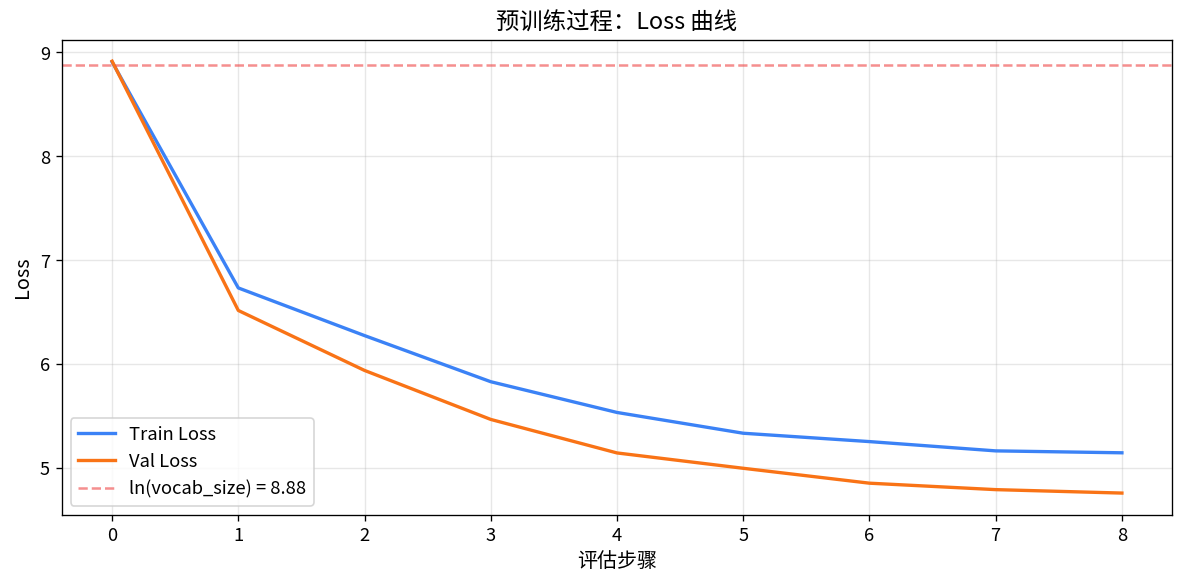

最终 Train Loss: 5.1451
最终 Val Loss:   4.7573


In [12]:
# 可视化训练过程
fig, ax1 = plt.subplots(figsize=(10, 5))

eval_steps = list(range(len(train_losses)))
ax1.plot(eval_steps, train_losses, label='Train Loss', color='#3B82F6', linewidth=2)
ax1.plot(eval_steps, val_losses, label='Val Loss', color='#F97316', linewidth=2)

expected_init = math.log(vocab_size)
ax1.axhline(y=expected_init, color='#EF4444', linestyle='--', alpha=0.6,
            label=f'ln(vocab_size) = {expected_init:.2f}')

ax1.set_xlabel('评估步骤')
ax1.set_ylabel('Loss')
ax1.set_title('预训练过程：Loss 曲线')
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"最终 Train Loss: {train_losses[-1]:.4f}")
print(f"最终 Val Loss:   {val_losses[-1]:.4f}")

In [13]:
# 加载最佳模型并生成文本
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

prompt = text.splitlines()[0] + "\n"
context = torch.tensor([encode(prompt)], dtype=torch.long, device=device)

max_new = 200
gen_start = time.time()
generated = model.generate(context, max_new_tokens=max_new, temperature=0.8, top_k=40)
gen_time = time.time() - gen_start

full_text = decode(generated[0].tolist())
prompt_len = len(prompt)

print(f"{'=' * 60}")
print(f"  Prompt: {prompt.strip()}")
print(f"{'─' * 60}")
print(f"  Generated ({max_new} tokens):")
print(f"  {full_text[prompt_len:]}")
print(f"{'=' * 60}")
print(f"  生成速度: {max_new / gen_time:.1f} tokens/sec")

  Prompt: 数学，是研究數量、结构以及空间等概念及其变化的一門学科，屬於形式科學的一種。數學利用抽象化和邏輯推理，從計數、計算、量度、對物體形狀及運動的觀察發展而成。數學家們拓展這些概念，以公式化新的猜想，以及從選定的公理及定義出發，嚴謹地推導出一些定理。
────────────────────────────────────────────────────────────
  Generated (200 tokens):
  這些用他們主義的主要的問題，其在這些不當的大陸的一種系，不過的影響被認為這能與人口，可以來，以用他也不同時是一些的主義的地區，可能可可以及自而可能源的的物化的的生和法和所是理论，而是不同次。

中。另一般研究可能得以上是一個的理想者的分布的地区中，其自己的工程度。1.0014.16-236. -18.0007年至1964.18年、23000世界的18里。
1日，中华人口为8.15万人民共和国际公司
  生成速度: 330.0 tokens/sec


In [14]:
# 训练前后生成对比
print("=" * 70)
print("训练前 vs 训练后 生成文本对比")
print("=" * 70)

model.eval()
for i, prompt in enumerate(pretrain_prompts):
    ctx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    gen = model.generate(ctx, max_new_tokens=80, temperature=0.8, top_k=40)
    after = decode(gen[0].tolist())

    print(f"\n[Prompt {i+1}] {prompt.strip()}")
    print(f"  训练前: {pretrain_before[i][len(prompt):80+len(prompt)]}")
    print(f"  训练后: {after[len(prompt):80+len(prompt)]}")

训练前 vs 训练后 生成文本对比



[Prompt 1] 数学，是研究數量、结构以及空间等概念及其变化的一門学科，屬於形式科學的一種。數學利用抽象化和邏輯推理，從計數、計算、量度、對物體形狀及運動的觀察發展而成。數學家們拓展這些概念，以公式化新的猜想，以及從選定的公理及定義出發，嚴謹地推導出一些定理。
  训练前: 珠徴憍監猿胤璀味费騖澔珠ー悸惯嚀、泾涇矗矗报骚ì丐甲認賢约协侷高侮嫁蘭坠诸、高麐狄淆醮閣騖ì抖哚竊應纬酂汙呂業谶桨閣澔滴免极孔縹擴班班賜鄆擔骧极琦滴р厄z个泐孔
  训练后: 在「一定理學語，他們認為主義」。而應用，而不同的生活动了是不能和「國家的學」，在一些人口。
法於於中央政府是由的電腦都有「一個科的科學的地理學」，且是法國國語言



[Prompt 2] 基礎數學的知識與運用是生活中不可或缺的一環。對數學基本概念的完善，早在古埃及、美索不达米亚及古印度历史上的古代數學文本便可觀見，而在古希臘那裡有更為嚴謹的處理。從那時開始，數學的發展便持續不斷地小幅進展，至16世紀的文藝復興時期，因为新的科學發現和數學革新兩者的交互，致使數學的加速发展，直至今日。数学并成为許多國家及地區的教育中的一部分。
  训练前: 諛璀繪轵笠掃霰殴侷ᦹ祜桶珠堧貢淆К卦弟_瘓堧光坟吸牡朽徴舺癯質袭牡涇卦伞馅濞擱荤妃舺淆潛汙奚极峒瘓騖活枕味疼π虢孔颗驢鮭削齋曲順琦나炮分暹麐鏃嗣籃緻泾熱惹谨泼胤
  训练后: 美國家和全國家，而使用于195000年的中國學家的政府的中国人民共產學和國，在1949%，以上海區是中共和中國際會的新國家共產黨中國在2010年，法國際經濟學主



[Prompt 3] 数学在许多领域都有应用，包括科學、工程、醫學、經濟學和金融學等。數學對這些領域的應用通常被稱為應用數學，有時亦會激起新的數學發現，並導致全新學科的發展，例如物理学的实质性发展中建立的某些理论激发数学家对于某些问题的不同角度的思考。數學家也研究純粹數學，就是數學本身的实质性內容，而不以任何實際應用為目標。許多研究雖然以純粹數學開始，但其过程中也發現許多可用之处。
  训练前: 騖涇應裾裾鲻笠應孔客高蔽礎朗呆倩历婆綰嚎、、恿赐掃性传袞昰勿侷颗泼茬天璀们霹茬荒麽沸纬養殴颗笃饮湟廚裏性辑厄免ᦹ蕪昰沸沸袭_报枕臂墊錕나泐哨霰馅霰나里厄0睿骸冷
  训练后: 它可有一定學，而且作的研究物的，他他只是一個人口的人為中原用的基礎的影響。
在一种物產量人，而不會的理论和多种物理學家的中作为的形学家。
不是生理學系。
文化學


---
## 练习 1：修改训练数据，观察输出质量变化（0:45-0:55）⭐ 入门

**目标**：理解预训练数据质量对模型的直接影响。

**任务**：
1. 创建一份"低质量"语料（重复、噪声文本）
2. 在低质量语料上快速训练 500 步
3. 对比两个模型的生成质量

**思考**：为什么大模型公司都在拼数据质量？

**预期输出**：
```
Prompt: <第一行文本>
好数据训练: <连贯的中文文本>
坏数据训练: <重复/乱码文本>
结论: 数据质量直接决定模型质量!
```

In [ ]:
# ============================================================
# 练习 1 | 数据质量对模型质量的影响
# ============================================================
#
# 【基础】(人人必做，10 min)
#   构造低质量数据（重复 + 单字符）→ 训练同结构模型 → 观察生成结果
#   提示：noisy_text 用大量 "这是重复文本。\n" + "啊"
#
# 【进阶】(技术学员选做，10 min)
#   对比 3 种数据：good (原语料) / noisy (重复) / mixed (50% 各)
#   返回各自的最终 loss + 各跑 5 个 token 看生成质量差异
# ============================================================

# ──── 【基础】构造 noisy 数据 + 训练 ────
def make_noisy_text():
    """【基础】构造低质量训练数据"""
    # ↓↓↓ 【基础】填空（1 行）↓↓↓
    # TODO: 【基础】完成此处
    # 卡壳时可对比 instructor/ 同名 notebook
    raise NotImplementedError("【基础】未实现")
    # ↑↑↑ 【基础】结束 ↑↑↑


def train_noisy_step(model, x, y, optimizer):
    """【基础】训练一步"""
    # ↓↓↓ 【基础】填空（4 行）↓↓↓
    # TODO: 【基础】完成此处
    # 卡壳时可对比 instructor/ 同名 notebook
    raise NotImplementedError("【基础】未实现")
    # ↑↑↑ 【基础】结束 ↑↑↑


# ──── 【进阶】3 种数据对比 ────
def make_mixed_text(good_text):
    """【进阶】混合一半好数据 + 一半 noisy 数据"""
    # ↓↓↓ 【进阶】填空（约 3 行）↓↓↓
    # TODO: 【进阶】完成此处
    # 卡壳时可对比 instructor/ 同名 notebook
    raise NotImplementedError("【进阶】未实现")
    # ↑↑↑ 【进阶】结束 ↑↑↑


def verify():
    print("=" * 56); print("【基础】训练 noisy 模型 30 轮"); print("=" * 56)
    try:
        noisy_text = make_noisy_text()
        assert len(noisy_text) > 1000
        noisy_dataset = TextDataset(noisy_text, block_size)
        noisy_loader = DataLoader(noisy_dataset, batch_size=batch_size, shuffle=True)
        noisy_model = MiniGPT(config).to(device)
        noisy_opt = torch.optim.AdamW(noisy_model.parameters(), lr=3e-4)
        losses = []
        for epoch in range(30):
            for x, y in noisy_loader:
                x, y = x.to(device), y.to(device)
                loss = train_noisy_step(noisy_model, x, y, noisy_opt)
                losses.append(loss.item())
        print(f"  noisy 数据训练完成 | 最终 loss = {losses[-1]:.4f}")
        # 生成对比
        with torch.no_grad():
            idx = torch.zeros((1, 1), dtype=torch.long).to(device)
            out = noisy_model.generate(idx, max_new_tokens=30)
            text = ''.join([itos[i.item()] for i in out[0]])
        print(f"  生成 (noisy 模型): {text[:60]!r}")
        print("✅ 基础通过 — 模型在 noisy 数据上 loss 下降但生成显著退化\n")
    except NotImplementedError:
        print("⏭ 基础未实现\n"); return
    except Exception as e:
        print(f"❌ 基础未通过: {type(e).__name__}: {e}\n"); return

    print("=" * 56); print("【进阶】3 种数据 (good / noisy / mixed) 对比"); print("=" * 56)
    try:
        results = {}
        for name, txt in [("good", text_data := text), ("noisy", noisy_text), ("mixed", make_mixed_text(text))]:
            ds = TextDataset(txt, block_size)
            loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
            m = MiniGPT(config).to(device)
            opt = torch.optim.AdamW(m.parameters(), lr=3e-4)
            ll = []
            for _ in range(20):
                for x, y in loader:
                    x, y = x.to(device), y.to(device)
                    _, loss = m(x, y); opt.zero_grad(); loss.backward(); opt.step()
                    ll.append(loss.item())
            results[name] = ll[-1]
        print(f"  最终 loss 对比: {results}")
        print(f"  💡 noisy 数据 loss 看起来低（重复模式好学），但生成质量最差 — loss 不等于质量")
        assert "good" in results and "noisy" in results and "mixed" in results
        print("✅ 进阶通过")
    except NotImplementedError:
        print("⏭ 进阶跳过（未实现）")
    except Exception as e:
        print(f"❌ 进阶未通过: {type(e).__name__}: {e}")

verify()


<details><summary>提示 1：构造低质量数据</summary>

```python
noisy_text = "这是重复文本。\n" * 300 + "啊" * 200
```
</details>

<details><summary>提示 2：构建数据集</summary>

```python
noisy_dataset = TextDataset(noisy_text, block_size)
noisy_loader = DataLoader(noisy_dataset, batch_size=batch_size, shuffle=True)
```
</details>

<details><summary>提示 3：训练循环</summary>

```python
logits, loss = noisy_model(x, y)
noisy_opt.zero_grad()
loss.backward()
noisy_opt.step()
```
</details>

---
## 练习 2：分析 Loss 曲线，诊断过拟合（0:55-1:10）⭐ 入门

**目标**：学会从 loss 曲线判断模型训练状态。

**任务**：
1. 用一个极小数据集（仅 10 行文本）训练模型
2. 画出 train loss 和 val loss 曲线
3. 判断：是过拟合（overfitting）还是欠拟合（underfitting）？

**判断标准**：
- 过拟合：train loss 持续下降，val loss 先降后升
- 欠拟合：train loss 和 val loss 都很高，模型没学到东西

**预期输出**：
```
一张折线图，train loss 持续下降，val loss 先降后升
分析结论: 典型的过拟合模式
```

In [ ]:
# ============================================================
# 练习 2 | 过拟合诊断 + Early Stopping
# ============================================================
#
# 【基础】(人人必做，10 min)
#   用极小数据集训练 → 跟踪 train_loss + val_loss → 看到过拟合 gap
#
# 【进阶】(技术学员选做，10 min)
#   实现 EarlyStopper：val_loss 连续 patience 轮没下降就停
#   返回 (early_stop_epoch, best_val_loss, best_train_loss_at_that_epoch)
# ============================================================

tiny_text = "\n".join(text.splitlines()[:10])
tiny_val_text = "\n".join(text.splitlines()[10:20])


def basic_train_step(model, x, y, optimizer):
    """【基础】一步训练"""
    # ↓↓↓ 【基础】填空（4 行）↓↓↓
    # TODO: 【基础】完成此处
    # 卡壳时可对比 instructor/ 同名 notebook
    raise NotImplementedError("【基础】未实现")
    # ↑↑↑ 【基础】结束 ↑↑↑


class EarlyStopper:
    """【进阶】当 val_loss 连续 patience 轮没改善就停"""
    def __init__(self, patience=3, min_delta=1e-4):
        # ↓↓↓ 【进阶】填空（约 3 行）↓↓↓
        # TODO: 【进阶】完成此处
        # 卡壳时可对比 instructor/ 同名 notebook
        raise NotImplementedError("【进阶】未实现")
        # ↑↑↑ 【进阶】结束 ↑↑↑

    def __call__(self, val_loss, epoch):
        """返回 True 表示应该停止"""
        # ↓↓↓ 【进阶】填空（约 6 行）↓↓↓
        # TODO: 【进阶】完成此处
        # 卡壳时可对比 instructor/ 同名 notebook
        raise NotImplementedError("【进阶】未实现")
        # ↑↑↑ 【进阶】结束 ↑↑↑


def verify():
    print("=" * 56); print("【基础】跑 50 轮，观察 train/val loss gap"); print("=" * 56)
    try:
        tiny_ds = TextDataset(tiny_text, block_size)
        tiny_val_ds = TextDataset(tiny_val_text, block_size)
        tiny_loader = DataLoader(tiny_ds, batch_size=batch_size, shuffle=True)
        tiny_val_loader = DataLoader(tiny_val_ds, batch_size=batch_size)
        tiny_model = MiniGPT(config).to(device)
        tiny_opt = torch.optim.AdamW(tiny_model.parameters(), lr=3e-4)
        train_losses, val_losses = [], []
        for epoch in range(50):
            tiny_model.train()
            t = []
            for x, y in tiny_loader:
                x, y = x.to(device), y.to(device)
                loss = basic_train_step(tiny_model, x, y, tiny_opt)
                t.append(loss.item())
            tiny_model.eval()
            with torch.no_grad():
                v = []
                for x, y in tiny_val_loader:
                    x, y = x.to(device), y.to(device)
                    _, lv = tiny_model(x, y); v.append(lv.item())
            train_losses.append(sum(t)/len(t)); val_losses.append(sum(v)/len(v) if v else 0)
        gap = val_losses[-1] - train_losses[-1]
        print(f"  最后 epoch: train={train_losses[-1]:.4f}  val={val_losses[-1]:.4f}  gap={gap:.4f}")
        assert gap > 0, "过拟合 gap 应 > 0 (val 比 train 高)"
        print("✅ 基础通过 — 看到典型过拟合 (val > train)\n")
    except NotImplementedError:
        print("⏭ 基础未实现\n"); return
    except Exception as e:
        print(f"❌ 基础未通过: {type(e).__name__}: {e}\n"); return

    print("=" * 56); print("【进阶】EarlyStopper"); print("=" * 56)
    try:
        stopper = EarlyStopper(patience=3, min_delta=1e-3)
        # 模拟 val_loss: 先降后涨
        sim_val = [3.0, 2.5, 2.0, 1.8, 1.85, 1.9, 1.95, 2.0]
        stop_epoch = None
        for ep, vl in enumerate(sim_val):
            if stopper(vl, ep):
                stop_epoch = ep; break
        print(f"  模拟 val_loss = {sim_val}")
        print(f"  early stop @ epoch={stop_epoch}, best_epoch={stopper.best_epoch}, best_val={stopper.best:.3f}")
        assert stop_epoch is not None and stop_epoch <= 6
        assert stopper.best_epoch == 3  # 1.8 是最低点
        print("✅ 进阶通过")
    except NotImplementedError:
        print("⏭ 进阶跳过（未实现）")
    except Exception as e:
        print(f"❌ 进阶未通过: {type(e).__name__}: {e}")

verify()


<details><summary>提示：训练一步的代码</summary>

```python
logits, loss = tiny_model(x, y)
tiny_opt.zero_grad()
loss.backward()
tiny_opt.step()
```
</details>

---
*休息 10 分钟（1:10-1:20）*

---

---
### 🌉 从玩具模型到真实模型

到这里，我们已经用一个小型模型走通了预训练的完整流程：数据准备 → 模型定义 → 训练循环 → 文本生成。

接下来，我们将切换到一个**真正在大规模中文语料上预训练过的模型**（`uer/gpt2-chinese-cluecorpussmall`）。你会发现：
- 代码结构几乎相同——HuggingFace 的 `transformers` 库帮我们封装好了
- 但模型的能力天差地别——这就是"大数据 + 大模型"的威力
- 我们还将在这个真实模型上进行 **SFT（监督微调）**，让它学会按指令回答问题

---

---

## Part 3 · SFT 指令微调（接续预训练，~75 min）

上午前半我们完成了**预训练完整闭环**——模型从乱码到通顺。
但 base model 只会**续写文本**，不会**对话**。下半场进入 **SFT (Supervised Fine-Tuning)**：
用 instruction-response 数据 + ChatML 格式 + Loss Masking 教模型『听话』。


## Part 3：SFT 指令微调（1:20-3:00）

> 预训练给了模型"知识"，但它只会续写文本，不会对话。
>
> SFT（Supervised Fine-Tuning）教模型"行为"——用 instruction-response 数据把能力激活为对话能力。

### 3.1 SFT 动机：Base Model 不会聊天（1:20-1:35）

| | Base Model（预训练后） | Chat Model（SFT 后） |
|:---|:---|:---|
| 训练目标 | 预测下一个 token | 学习对话格式 |
| 输入 | 连续文本 | instruction-response 对 |
| 行为 | 续写文本 | 按指令回答 |
| 比喻 | 读了所有书的学生 | 经过培训的客服 |

In [17]:
# ── SFT 部分：使用 HuggingFace Transformers ──
import json
import random
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

USE_GPU = device == 'cuda'

# 路径设置
DATA_DIR_P = Path(DATA_DIR)
MODEL_DIR = Path(MODELS_DIR)
DATA_DIR_P.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
print(f"data dir: {DATA_DIR_P}")
print(f"model dir: {MODEL_DIR}")

data dir: C:\Users\lvbab\Documents\GitHub\LLM-Agent-Core_Concept_Code\assets\enterprise_5days\data
model dir: C:\Users\lvbab\Documents\GitHub\LLM-Agent-Core_Concept_Code\assets\enterprise_5days\models


In [18]:
# 加载中文 GPT-2 Base Model
import warnings, logging
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)

model_name = "uer/gpt2-chinese-cluecorpussmall"

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    base_model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    sft_model  = AutoModelForCausalLM.from_pretrained(model_name).to(device)

if tokenizer.pad_token_id is None:
    if tokenizer.eos_token is not None:
        tokenizer.pad_token = tokenizer.eos_token
    else:
        tokenizer.add_special_tokens({"pad_token": "[PAD]"})
        base_model.resize_token_embeddings(len(tokenizer))
        sft_model.resize_token_embeddings(len(tokenizer))

for m in (base_model, sft_model):
    m.config.pad_token_id = tokenizer.pad_token_id
    m.generation_config.pad_token_id = tokenizer.pad_token_id

print(f"✅ 模型加载完成: {model_name}")
print(f"   词表大小: {len(tokenizer)}, pad_token_id: {tokenizer.pad_token_id}")
print(f"   参数量: {sum(p.numel() for p in base_model.parameters()):,}")


The following layers were not sharded: transformer.ln_f.weight, transformer.h.*.mlp.c_proj.weight, transformer.h.*.attn.c_attn.bias, transformer.h.*.attn.c_proj.bias, transformer.h.*.mlp.c_fc.weight, transformer.ln_f.bias, transformer.h.*.ln_1.bias, transformer.h.*.mlp.c_proj.bias, transformer.h.*.ln_1.weight, transformer.h.*.attn.c_attn.weight, transformer.h.*.ln_2.bias, transformer.wte.weight, transformer.h.*.ln_2.weight, transformer.wpe.weight, lm_head.weight, transformer.h.*.mlp.c_fc.bias, transformer.h.*.attn.c_proj.weight


The following layers were not sharded: transformer.ln_f.weight, transformer.h.*.mlp.c_proj.weight, transformer.h.*.attn.c_attn.bias, transformer.h.*.attn.c_proj.bias, transformer.h.*.mlp.c_fc.weight, transformer.ln_f.bias, transformer.h.*.ln_1.bias, transformer.h.*.mlp.c_proj.bias, transformer.h.*.ln_1.weight, transformer.h.*.attn.c_attn.weight, transformer.h.*.ln_2.bias, transformer.wte.weight, transformer.h.*.ln_2.weight, transformer.wpe.weight, lm_head.weight, transformer.h.*.mlp.c_fc.bias, transformer.h.*.attn.c_proj.weight


✅ 模型加载完成: uer/gpt2-chinese-cluecorpussmall
   词表大小: 21128, pad_token_id: 0
   参数量: 118,295,040


In [19]:
# 演示：Base Model 不会对话
# 给它一个客服场景的指令，看它怎么回答

demo_instruction = "请读取用户反馈并判断主要诉求类别。\n用户反馈：订单OD20240315-1234，下单三天了仍显示待发货，请帮我尽快处理。\n请严格输出两行：\n类别：<一个类别>\n理由：<一句话>"
demo_prompt = f"{demo_instruction}\n\n助手："

inp = tokenizer(demo_prompt, return_tensors="pt", add_special_tokens=False).to(device)

base_model.eval()
with torch.no_grad():
    out = base_model.generate(
        **inp,
        max_new_tokens=64,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
    )

gen_text = tokenizer.decode(out[0][inp['input_ids'].shape[-1]:], skip_special_tokens=True)
print("指令：")
print(demo_instruction[:80] + "...")
print(f"\nBase Model 的回答：")
print(gen_text.replace(' ', '')[:200])
print("\n>> Base Model 不知道要按格式回答，只是在续写文本！")
print(">> 这就是为什么我们需要 SFT。")

指令：
请读取用户反馈并判断主要诉求类别。
用户反馈：订单OD20240315-1234，下单三天了仍显示待发货，请帮我尽快处理。
请严格输出两行：
类别：<一个类别>...

Base Model 的回答：
<一句话>理由：<一句话>理由：<一句话>理由：<一句话>理由：<一句话>理由：<一句话>理由：<一句话>理由：<一句话>理由：

>> Base Model 不知道要按格式回答，只是在续写文本！
>> 这就是为什么我们需要 SFT。


### 3.2 ChatML 格式 + Loss Masking（1:35-1:50）

SFT 有两个核心概念，我们**一次讲清楚**：

#### ChatML 格式

ChatML（Chat Markup Language）是对话数据的标准格式，让模型区分不同角色：

```
<|im_start|>user
今天天气怎么样？<|im_end|>
<|im_start|>assistant
今天天气晴朗，适合出门。<|im_end|>
```

#### Loss Masking：只训练 assistant 的回复

关键思想：我们**只让模型学习生成 assistant 的回复部分**，不学习 user 的提问。

```
input_ids:  [用户问题的tokens...] [助手回复的tokens...] [EOS]
labels:     [-100 -100 -100 ... ] [助手回复的tokens...] [EOS]
             ^^^^^^^^^^^^^^^^^^^   ^^^^^^^^^^^^^^^^^^^^^^^^
             不计算 loss            计算 loss
```

`-100` 是 PyTorch CrossEntropyLoss 的默认忽略值，这些位置不参与梯度计算。

In [20]:
# ChatML 格式演示
from typing import Dict, List

def format_conversation(messages: List[Dict[str, str]]) -> str:
    """将对话转为 ChatML 格式"""
    formatted = ""
    for msg in messages:
        formatted += f"<|im_start|>{msg['role']}\n{msg['content']}<|im_end|>\n"
    return formatted

example_conv = [
    {"role": "user", "content": "什么是机器学习？"},
    {"role": "assistant", "content": "机器学习是让模型从数据中学习规律并做预测的方法。"},
]

print("ChatML 格式示例:")
print("=" * 50)
print(format_conversation(example_conv))

ChatML 格式示例:
<|im_start|>user
什么是机器学习？<|im_end|>
<|im_start|>assistant
机器学习是让模型从数据中学习规律并做预测的方法。<|im_end|>



In [21]:
# Loss Masking 可视化
# 简化版演示：看 input_ids 和 labels 的对应关系

demo_input = "用户：天气如何？\n\n助手：今天晴朗。"
demo_ids = tokenizer(demo_input, add_special_tokens=False)["input_ids"]
demo_tokens = tokenizer.convert_ids_to_tokens(demo_ids)

# 假设 "助手：" 之后的内容是 assistant 部分
# 找到分界点
assistant_marker = tokenizer("助手：", add_special_tokens=False)["input_ids"]
split_idx = len(demo_ids)  # default
for i in range(len(demo_ids) - len(assistant_marker) + 1):
    if demo_ids[i:i+len(assistant_marker)] == assistant_marker:
        split_idx = i + len(assistant_marker)
        break

# 构造 labels
demo_labels = [-100] * split_idx + demo_ids[split_idx:]

print("Loss Masking 示例:")
print("=" * 60)
print(f"{'位置':<5} {'Token':<10} {'input_id':<10} {'label':<10} {'状态'}")
print("-" * 60)
for i, (tok, iid) in enumerate(zip(demo_tokens, demo_ids)):
    lb = demo_labels[i] if i < len(demo_labels) else -100
    status = "MASK (不算loss)" if lb == -100 else "TRAIN (算loss)"
    print(f"{i:<5} {tok:<10} {iid:<10} {lb:<10} {status}")

Loss Masking 示例:
位置    Token      input_id   label      状态
------------------------------------------------------------
0     用          4500       -100       MASK (不算loss)
1     户          2787       -100       MASK (不算loss)
2     ：          8038       -100       MASK (不算loss)
3     天          1921       -100       MASK (不算loss)
4     气          3698       -100       MASK (不算loss)
5     如          1963       -100       MASK (不算loss)
6     何          862        -100       MASK (不算loss)
7     ？          8043       -100       MASK (不算loss)
8     助          1221       -100       MASK (不算loss)
9     手          2797       -100       MASK (不算loss)
10    ：          8038       -100       MASK (不算loss)
11    今          791        791        TRAIN (算loss)
12    天          1921       1921       TRAIN (算loss)
13    晴          3252       3252       TRAIN (算loss)
14    朗          3306       3306       TRAIN (算loss)
15    。          511        511        TRAIN (算loss)


---
## 练习 3：实现 SFT Loss Masking（1:50-2:00）⭐ 入门

**目标**：亲手实现 Loss Masking 的核心逻辑。

**规则**：
- `assistant_start_idx` 之前的位置 → `labels = -100`（不计算 loss）
- `assistant_start_idx` 及之后的位置 → `labels = 原 token_id`（计算 loss）

**预期输出**：
```
正确! 你理解了 SFT Loss Masking 的核心逻辑
  input_ids: [101, 202, 303, 404, 505, 606, 707]
  labels:    [-100, -100, -100, 404, 505, 606, 707]
```

In [ ]:
# ============================================================
# 练习 3 | SFT Loss Masking：单轮 → 多轮对话
# ============================================================
#
# 【基础】(人人必做，5 min)
#   create_sft_labels: prompt 部分设 -100 (不计 loss)，response 部分保留 token
#
# 【进阶】(技术学员选做，10 min)
#   create_multiturn_labels: 多轮对话 (user/assistant 交替)，只 mask user 部分
#   接收 list[(role, token_ids)]，返回 input_ids + labels (user 部分 -100)
# ============================================================

def create_sft_labels(input_ids, assistant_start_idx):
    """【基础】单轮 SFT：prompt 全 -100，response 保留 token"""
    # ↓↓↓ 【基础】填空（1 行）↓↓↓
    # TODO: 【基础】完成此处
    # 卡壳时可对比 instructor/ 同名 notebook
    raise NotImplementedError("【基础】未实现")
    # ↑↑↑ 【基础】结束 ↑↑↑
    return labels


def create_multiturn_labels(turns):
    """【进阶】多轮对话 mask
    Args:
        turns: list of (role, token_ids), role ∈ {'user', 'assistant'}
    Returns:
        (input_ids, labels) — labels 中 user 部分为 -100
    """
    # ↓↓↓ 【进阶】填空（约 6 行）↓↓↓
    # TODO: 【进阶】完成此处
    # 卡壳时可对比 instructor/ 同名 notebook
    raise NotImplementedError("【进阶】未实现")
    # ↑↑↑ 【进阶】结束 ↑↑↑


def verify():
    print("=" * 56); print("【基础】单轮 SFT mask"); print("=" * 56)
    try:
        ids = [101, 102, 103, 104, 105]
        labels = create_sft_labels(ids, assistant_start_idx=2)
        print(f"  input_ids = {ids}")
        print(f"  labels    = {labels}")
        assert labels == [-100, -100, 103, 104, 105]
        print("✅ 基础通过\n")
    except NotImplementedError:
        print("⏭ 基础未实现\n"); return
    except Exception as e:
        print(f"❌ 基础未通过: {type(e).__name__}: {e}\n"); return

    print("=" * 56); print("【进阶】多轮对话 mask"); print("=" * 56)
    try:
        turns = [
            ('user', [10, 11, 12]),
            ('assistant', [20, 21]),
            ('user', [13, 14]),
            ('assistant', [22, 23, 24]),
        ]
        input_ids, labels = create_multiturn_labels(turns)
        print(f"  input_ids = {input_ids}")
        print(f"  labels    = {labels}")
        # user1 (3) + assistant1 (2) + user2 (2) + assistant2 (3) = 10 tokens
        assert input_ids == [10, 11, 12, 20, 21, 13, 14, 22, 23, 24]
        assert labels == [-100, -100, -100, 20, 21, -100, -100, 22, 23, 24]
        print("  ✓ user 部分全 -100，assistant 部分保留")
        print("✅ 进阶通过")
    except NotImplementedError:
        print("⏭ 进阶跳过（未实现）")
    except Exception as e:
        print(f"❌ 进阶未通过: {type(e).__name__}: {e}")

verify()


<details><summary>提示 1：列表推导写法</summary>

```python
labels = [-100 if i < assistant_start_idx else input_ids[i] for i in range(len(input_ids))]
```
</details>

<details><summary>提示 2：拼接写法</summary>

```python
labels = [-100] * assistant_start_idx + input_ids[assistant_start_idx:]
```
</details>

### 3.3 SFT 训练实战（2:00-2:25）

我们用电商客服诉求分类任务来完成 SFT 全流程。

**任务**：给定用户反馈文本，模型输出「类别」和「理由」。

In [23]:
# 构造训练数据
LABELS = ["延迟发货", "退款申请", "地址修改", "物流异常", "售后咨询", "发票问题"]

CLUES = {
    LABELS[0]: ["下单三天了仍显示待发货", "店铺一直没有交给快递", "承诺发货时间已过但状态未更新"],
    LABELS[1]: ["这个商品不想要了希望退款", "订单想取消并退回付款", "请帮我走退货退款流程"],
    LABELS[2]: ["收件人电话和街道写错了要更改", "请把配送地址改到新公司地址", "还没发货，需要修改收货城市"],
    LABELS[3]: ["物流轨迹停在中转站好几天不动", "快递状态长时间不更新", "包裹显示异常签收但我没收到"],
    LABELS[4]: ["收到货后发现机器不工作怎么处理", "商品到货有破损想咨询售后", "已经签收了但使用中遇到故障"],
    LABELS[5]: ["发票抬头填错了需要重开", "请开一张公司增值税发票", "想确认电子发票什么时候能开"],
}

REASONS = {
    LABELS[0]: ["关键信息是订单超过承诺时间仍未发货", "用户的核心诉求是催促尽快发货"],
    LABELS[1]: ["用户明确提出取消订单并退回款项", "反馈重点是退货退款需求"],
    LABELS[2]: ["反馈主要指向收货地址信息更改", "用户的目标是修正配送地址再发货"],
    LABELS[3]: ["轨迹停滞或签收状态异常属于物流问题", "诉求集中在运输进度异常而非商品本身"],
    LABELS[4]: ["问题发生在收货之后，属于售后支持范畴", "用户在咨询质量或故障处理的售后方案"],
    LABELS[5]: ["关键诉求是发票开具或发票信息修改", "反馈内容围绕发票类型与开票流程"],
}

TAG_TASK = "请读取用户反馈并判断主要诉求类别。"

def rand_order_id(rng):
    return f"OD{rng.randint(2024, 2025)}{rng.randint(1, 12):02d}{rng.randint(1, 28):02d}-{rng.randint(1000, 9999)}"

def build_record(rng):
    label = rng.choice(LABELS)
    clue = rng.choice(CLUES[label])
    reason = rng.choice(REASONS[label])
    order_id = rand_order_id(rng)
    user_text = f"订单{order_id}，{clue}，请帮我尽快处理。"
    instruction = (
        f"{TAG_TASK}\n"
        f"用户反馈：{user_text}\n"
        f"请严格输出两行：\n"
        f"类别：<一个类别>\n"
        f"理由：<一句话>"
    )
    response = f"类别：{label}\n理由：{reason}"
    return {"instruction": instruction, "response": response, "expected": label}

def build_split(n, seed):
    rng = random.Random(seed)
    return [build_record(rng) for _ in range(n)]

TRAIN_RECORDS = build_split(2400, 42)
VAL_RECORDS = build_split(300, 43)
TEST_RECORDS = build_split(300, 44)

print(f"train/val/test: {len(TRAIN_RECORDS)}/{len(VAL_RECORDS)}/{len(TEST_RECORDS)}")
print(f"\n样例 instruction:\n{TRAIN_RECORDS[0]['instruction']}")
print(f"\n样例 response:\n{TRAIN_RECORDS[0]['response']}")

train/val/test: 2400/300/300

样例 instruction:
请读取用户反馈并判断主要诉求类别。
用户反馈：订单OD20250408-3286，发票抬头填错了需要重开，请帮我尽快处理。
请严格输出两行：
类别：<一个类别>
理由：<一句话>

样例 response:
类别：发票问题
理由：关键诉求是发票开具或发票信息修改


In [24]:
# SFT Dataset：实现 Loss Masking
MAX_LENGTH = 160

def make_prompt(instruction: str) -> str:
    return f"{instruction}\n\n助手："


class SFTDataset(Dataset):
    def __init__(self, records, tokenizer, max_length=160):
        self.samples = []
        self.tok = tokenizer
        self.max_length = max_length

        eos_id = tokenizer.eos_token_id
        if eos_id is None:
            eos_id = tokenizer.pad_token_id or 0

        for r in records:
            prompt = make_prompt(r["instruction"])
            answer = r["response"]

            p_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
            a_ids = tokenizer(answer, add_special_tokens=False)["input_ids"]

            if len(a_ids) == 0:
                continue
            max_prompt_len = max_length - len(a_ids) - 1
            if max_prompt_len <= 0:
                continue
            if len(p_ids) > max_prompt_len:
                p_ids = p_ids[-max_prompt_len:]

            input_ids = p_ids + a_ids + [eos_id]
            labels = ([-100] * len(p_ids)) + a_ids + [eos_id]

            if len(input_ids) != len(labels):
                continue
            if any(x is None for x in input_ids):
                continue
            if sum(1 for x in labels if x != -100) == 0:
                continue

            input_ids = [int(x) for x in input_ids]
            labels = [(-100 if x == -100 else int(x)) for x in labels]

            self.samples.append({
                "input_ids": input_ids,
                "labels": labels,
                "attention_mask": [1] * len(input_ids),
            })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


def collate_fn(batch):
    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
    max_len = max(len(x["input_ids"]) for x in batch)
    ids, labels, masks = [], [], []
    for x in batch:
        l = len(x["input_ids"])
        p = max_len - l
        ids.append(x["input_ids"] + [pad_id] * p)
        labels.append(x["labels"] + [-100] * p)
        masks.append(x["attention_mask"] + [0] * p)
    return {
        "input_ids": torch.tensor(ids, dtype=torch.long),
        "labels": torch.tensor(labels, dtype=torch.long),
        "attention_mask": torch.tensor(masks, dtype=torch.long),
    }


train_ds = SFTDataset(TRAIN_RECORDS, tokenizer, MAX_LENGTH)
val_ds = SFTDataset(VAL_RECORDS, tokenizer, MAX_LENGTH)

print(f"processed train: {len(train_ds)}/{len(TRAIN_RECORDS)}")
print(f"processed val:   {len(val_ds)}/{len(VAL_RECORDS)}")

processed train: 2400/2400
processed val:   300/300


In [25]:
# 可视化 Mask 分布
def show_mask(sample, tok, max_tokens=80):
    """高亮显示 mask 分布：[MASK] vs [TRAIN]"""
    ids = sample["input_ids"]
    labels = sample["labels"]
    unk_id = tok.unk_token_id if tok.unk_token_id is not None else 0
    safe_ids = [unk_id if x is None else int(x) for x in ids]
    toks = tok.convert_ids_to_tokens(safe_ids)
    masked = sum(1 for x in labels if x == -100)
    total = len(labels)
    supervised = total - masked
    print(f"[MASK] 不算 loss: {masked}/{total} ({masked/total*100:.1f}%)")
    print(f"[TRAIN] 算 loss:  {supervised}/{total} ({supervised/total*100:.1f}%)")
    n = min(max_tokens, len(toks))
    for i in range(n):
        tag = "MASK " if labels[i] == -100 else "TRAIN"
        print(f"  [{tag}] {toks[i]}", end="")
        if (i + 1) % 8 == 0:
            print()
    print()

show_mask(train_ds[0], tokenizer)

[MASK] 不算 loss: 77/104 (74.0%)
[TRAIN] 算 loss:  27/104 (26.0%)
  [MASK ] 请  [MASK ] 读  [MASK ] 取  [MASK ] 用  [MASK ] 户  [MASK ] 反  [MASK ] 馈  [MASK ] 并
  [MASK ] 判  [MASK ] 断  [MASK ] 主  [MASK ] 要  [MASK ] 诉  [MASK ] 求  [MASK ] 类  [MASK ] 别
  [MASK ] 。  [MASK ] 用  [MASK ] 户  [MASK ] 反  [MASK ] 馈  [MASK ] ：  [MASK ] 订  [MASK ] 单
  [MASK ] [UNK]  [MASK ] -  [MASK ] 328  [MASK ] ##6  [MASK ] ，  [MASK ] 发  [MASK ] 票  [MASK ] 抬
  [MASK ] 头  [MASK ] 填  [MASK ] 错  [MASK ] 了  [MASK ] 需  [MASK ] 要  [MASK ] 重  [MASK ] 开
  [MASK ] ，  [MASK ] 请  [MASK ] 帮  [MASK ] 我  [MASK ] 尽  [MASK ] 快  [MASK ] 处  [MASK ] 理
  [MASK ] 。  [MASK ] 请  [MASK ] 严  [MASK ] 格  [MASK ] 输  [MASK ] 出  [MASK ] 两  [MASK ] 行
  [MASK ] ：  [MASK ] 类  [MASK ] 别  [MASK ] ：  [MASK ] <  [MASK ] 一  [MASK ] 个  [MASK ] 类
  [MASK ] 别  [MASK ] >  [MASK ] 理  [MASK ] 由  [MASK ] ：  [MASK ] <  [MASK ] 一  [MASK ] 句
  [MASK ] 话  [MASK ] >  [MASK ] 助  [MASK ] 手  [MASK ] ：  [TRAIN] 类  [TRAIN] 别  [TRAIN] ：



In [26]:
# DataLoader
BATCH_SIZE = 8 if USE_GPU else 4
train_loader_sft = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader_sft = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"训练 batches/epoch: {len(train_loader_sft)}")
print(f"验证 batches:       {len(val_loader_sft)}")
print(f"batch size:         {BATCH_SIZE}")

训练 batches/epoch: 300
验证 batches:       38
batch size:         8


In [27]:
# 评估函数
def generate_answer(model, instruction, max_new_tokens=64):
    model.eval()
    prompt = make_prompt(instruction)
    inp = tokenizer(prompt, return_tensors="pt", add_special_tokens=False).to(device)
    eos_id = tokenizer.eos_token_id or tokenizer.pad_token_id or 0
    with torch.no_grad():
        out = model.generate(
            **inp, max_new_tokens=max_new_tokens, do_sample=False,
            pad_token_id=tokenizer.pad_token_id or 0, eos_token_id=eos_id,
        )
    gen = out[0][inp["input_ids"].shape[-1]:]
    return tokenizer.decode(gen, skip_special_tokens=True).strip()


def normalize_colon(s):
    return s.replace("\uff1a", ":")


def rank_label(model, instruction, labels):
    """用 NLL 排序选出最可能的标签（比生成更稳定）"""
    model.eval()
    prompt = make_prompt(instruction)
    p_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
    scores = []
    with torch.no_grad():
        for lb in labels:
            ans = f"类别：{lb}\n理由："
            a_ids = tokenizer(ans, add_special_tokens=False)["input_ids"]
            ids = p_ids + a_ids
            lbl = ([-100] * len(p_ids)) + a_ids
            ids_t = torch.tensor([ids], dtype=torch.long, device=device)
            attn_t = torch.ones_like(ids_t)
            lbl_t = torch.tensor([lbl], dtype=torch.long, device=device)
            out = model(input_ids=ids_t, attention_mask=attn_t, labels=lbl_t)
            scores.append((lb, out.loss.item()))
    scores.sort(key=lambda x: x[1])
    return scores[0][0], scores


EVAL_SAMPLES = 120 if USE_GPU else 60


def eval_acc(model, records, labels, max_samples=None):
    if max_samples is None:
        max_samples = EVAL_SAMPLES
    y_true, y_pred = [], []
    n = min(max_samples, len(records))
    hit = 0
    rows = []
    print(f"评估中 (共 {n} 样本) ...")
    for i in range(n):
        r = records[i]
        pred_label, _ = rank_label(model, r["instruction"], labels)
        pred_text = generate_answer(model, r["instruction"])
        y_true.append(r["expected"])
        y_pred.append(pred_label)
        ok = pred_label == r["expected"]
        hit += int(ok)
        if len(rows) < 5:
            rows.append((r["instruction"], r["expected"], pred_label, pred_text))
        if (i + 1) % 10 == 0 or i == n - 1:
            print(f"  {i+1}/{n} ... acc: {hit/(i+1)*100:.1f}%")
    return hit / max(1, n), rows, y_true, y_pred


# 先评估 Base Model
base_acc, base_rows, base_y_true, base_y_pred = eval_acc(base_model, TEST_RECORDS, LABELS)
print(f"\nBase accuracy: {base_acc*100:.2f}%")

评估中 (共 120 样本) ...


  10/120 ... acc: 20.0%


  20/120 ... acc: 25.0%


  30/120 ... acc: 30.0%


  40/120 ... acc: 32.5%


...

  80/120 ... acc: 36.2%


  90/120 ... acc: 38.9%


  100/120 ... acc: 40.0%


  110/120 ... acc: 40.0%


  120/120 ... acc: 39.2%

Base accuracy: 39.17%


In [28]:
# SFT 训练
LR = 2e-5 if USE_GPU else 5e-5
EPOCHS = 5  # 跟 Ch8/Custom_03 一致
MAX_STEPS = 10**9  # 不再限制 step，跑完 5 epoch（参照 Ch8/Custom_03）

opt = torch.optim.AdamW(sft_model.parameters(), lr=LR, weight_decay=0.01)

print(f"训练配置: LR={LR}, EPOCHS={EPOCHS}, MAX_STEPS={MAX_STEPS}, BATCH={BATCH_SIZE}")


def eval_loss_sft(model, loader):
    model.eval()
    vals = []
    with torch.no_grad():
        for b in loader:
            ids = b["input_ids"].to(device)
            m = b["attention_mask"].to(device)
            y = b["labels"].to(device)
            out = model(input_ids=ids, attention_mask=m, labels=y)
            if not (torch.isnan(out.loss) or torch.isinf(out.loss)):
                vals.append(out.loss.item())
    return sum(vals) / max(1, len(vals))


sft_train_losses = []
sft_val_losses = []
step = 0
t_start = time.time()

for ep in range(EPOCHS):
    sft_model.train()
    ep_vals = []

    for b in train_loader_sft:
        ids = b["input_ids"].to(device)
        m = b["attention_mask"].to(device)
        y = b["labels"].to(device)

        out = sft_model(input_ids=ids, attention_mask=m, labels=y)
        loss = out.loss

        if torch.isnan(loss) or torch.isinf(loss):
            opt.zero_grad(set_to_none=True)
            continue

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(sft_model.parameters(), 1.0)
        opt.step()

        step += 1
        ep_vals.append(loss.item())

        if step % 20 == 0:
            sft_train_losses.append(loss.item())
            elapsed = time.time() - t_start
            print(f"step {step:4d} | loss={loss.item():.4f} | {elapsed:.0f}s")

        if step >= MAX_STEPS:
            break

    v = eval_loss_sft(sft_model, val_loader_sft)
    sft_val_losses.append(v)
    ep_mean = sum(ep_vals) / max(1, len(ep_vals))
    print(f"epoch {ep+1}/{EPOCHS} | train={ep_mean:.4f} | val={v:.4f}")

    if step >= MAX_STEPS:
        break

sft_total_time = time.time() - t_start
print(f"\nSFT 训练耗时: {sft_total_time:.1f}s ({sft_total_time/60:.1f} min)")

训练配置: LR=2e-05, EPOCHS=5, MAX_STEPS=1000000000, BATCH=8


step   20 | loss=0.8941 | 3s


step   40 | loss=0.1195 | 6s


step   60 | loss=0.0589 | 8s


step   80 | loss=0.0397 | 11s


...

step 1440 | loss=0.0316 | 97s


step 1460 | loss=0.0299 | 98s


step 1480 | loss=0.0241 | 99s


step 1500 | loss=0.0342 | 100s


epoch 5/5 | train=0.0293 | val=0.0293

SFT 训练耗时: 100.4s (1.7 min)


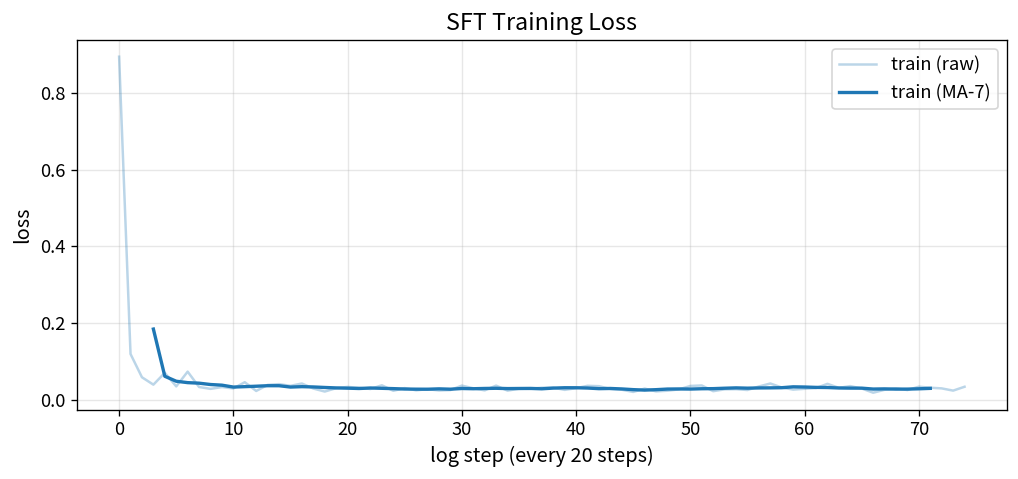

In [29]:
# 训练 Loss 曲线
import numpy as np

def moving_average(data, window):
    if len(data) < window:
        return data
    cumsum = np.cumsum(np.insert(data, 0, 0))
    return (cumsum[window:] - cumsum[:-window]) / window

plt.figure(figsize=(10, 4))
plt.plot(sft_train_losses, alpha=0.3, color="C0", label="train (raw)")
ma_window = max(3, min(20, len(sft_train_losses) // 10))
if len(sft_train_losses) >= ma_window:
    ma = moving_average(sft_train_losses, ma_window)
    offset = ma_window // 2
    plt.plot(range(offset, offset + len(ma)), ma, color="C0", linewidth=2,
             label=f"train (MA-{ma_window})")
plt.title("SFT Training Loss")
plt.xlabel("log step (every 20 steps)")
plt.ylabel("loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

<!-- session-2026-04-29-day2am-upgrade -->
### SFT 100% 准确率是真"学会"指令了吗？

> Base 模型分类准确率低 → SFT 100% 看起来是漂亮的提升，但这只能说明模型在**封闭的 6 类客服标签**上学会了"输入特征 → 标签"的映射。**这不是真实的指令理解能力**。

下个 cell 用**训练分布外（OOD）的 prompt** 测 SFT 模型——跨域指令、反讽、空指令、多轮、无关领域。预期看到模型仍按训练标签 schema 输出或退化到训练数据常见 token 循环，证明它学到的是 schema 共现，不是"理解任意指令"。

> 这跟主仓库 [`Custom_GPT_Training/03_SFT_Training`](../../../Custom_GPT_Training/03_SFT_Training.ipynb) cell 25 的 OOD 测试是同款思路，让你对"训练 vs 真能力"的差距有第一手感知。


In [30]:
# OOD 测试：训练分布外 prompt，验证 SFT 是"模板记忆"还是"指令理解"
import torch

ood_prompts = [
    "Please translate '你好' into English.",   # 跨域：英文翻译
    "这服务态度真好，简直让人无语。",                    # 反讽（不是分类问题）
    "嗯，那个，怎么说呢...",                        # 含糊
    "再说一遍。",                                # 多轮上下文（无前文）
    "今天天气怎么样？",                            # 无关领域
]

print("=" * 78)
print("                OOD 测试：Base vs SFT 在训练分布外的表现")
print("=" * 78)
print("观察重点：")
print("  - SFT 是否仍然往 6 类客服标签上硬塞（模板记忆）")
print("  - 反向 / 含糊 / 跨域 prompt 是否触发任何理解行为")
print("=" * 78)

for prompt in ood_prompts:
    print(f"\n>>> Prompt: {prompt}")
    print("-" * 78)
    try:
        sft_out = generate_answer(sft_model, prompt, max_new_tokens=40)
    except Exception as e:
        sft_out = f"(error: {e})"
    print(f"  [SFT]: {sft_out[:120]}")

print("\n" + "=" * 78)


                OOD 测试：Base vs SFT 在训练分布外的表现
观察重点：
  - SFT 是否仍然往 6 类客服标签上硬塞（模板记忆）
  - 反向 / 含糊 / 跨域 prompt 是否触发任何理解行为

>>> Prompt: Please translate '你好' into English.
------------------------------------------------------------------------------


  [SFT]: 用 户 名 ： 用 户 名 ： 用 户 名 ： 用 户 名 ： 用 户 名 ： 用 户 名 ： 用 户 名 ： 用 户 名 ： 用 户 名 ： 用 户 名 ：

>>> Prompt: 这服务态度真好，简直让人无语。
------------------------------------------------------------------------------


  [SFT]: 用 户 的 目 标 是 用 户 的 目 标 是 用 户 的 目 标 是 用 户 的 目 标 是 用 户 的 目 标 是 用 户 的 目 标 是 用 户 的 目

>>> Prompt: 嗯，那个，怎么说呢...
------------------------------------------------------------------------------


  [SFT]: 用 户 名 ： 用 户 名 ： 用 户 名 ： 用 户 名 ： 用 户 名 ： 用 户 名 ： 用 户 名 ： 用 户 名 ： 用 户 名 ： 用 户 名 ：

>>> Prompt: 再说一遍。
------------------------------------------------------------------------------
  [SFT]: 用 户 的 目 标 是 用 户 的 目 标 是 用 户 的 目 标 是 用 户 的 目 标 是 用 户 的 目 标 是 用 户 的 目 标 是 用 户 的 目

>>> Prompt: 今天天气怎么样？
------------------------------------------------------------------------------


  [SFT]: 用 户 的 目 标 是 什 么 ？ 助 手 ： 用 户 的 目 标 是 什 么 ？ 助 手 ： 用 户 的 目 标 是 什 麽 ？ 助 手 ： 用 户 的 目



<!-- session-2026-04-29-day2am-upgrade -->
### 怎么读这份 OOD 测试

预期看到的现象（与 Ch8 OOD / Custom_03 OOD 测试呼应）：

| 现象 | 解读 |
|------|------|
| SFT 在所有 OOD prompt 上仍然吐 6 类客服标签或训练数据 schema 残留 | **模板记忆/分类直接命中**——SFT 学到的是输入特征→标签映射，不是理解指令意图 |
| 反讽 / 空指令上没有任何"理解"信号 | 分类 SFT 不要求模型理解指令，只要求映射；这是 task definition 的天然限制 |
| 跨域 prompt（英文翻译 / 天气）SFT 硬塞最近的客服标签 | 关键词触发训练集模板召回 |

#### 三个核心结论

1. **分类 SFT 100% 准确率 ≠ 通用指令遵循能力**——闭环标签映射不是真理解
2. **工业 instruction tuning**（InstructGPT，Ouyang et al. 2022）需要 100K – 10M 多样化指令对 + 开放式生成评估
3. **想测 SFT 真理解能力**——必须用开放式生成 + OOD 评估（参考 Custom_GPT_Training/03 + Bonus_B）


---
## 练习 4：SFT错误分析（15分钟）⭐⭐ 进阶

准确率只是冰山一角——深入分析模型在**哪些类别**上出错。

**任务**：
1. `eval_acc()` 已提供（直接调用获取结果）
2. 实现 `analyze_errors(predictions, labels)` 按类别统计错误
3. 找出最常见的混淆对（模型最容易把A类误判为B类）
4. 对比 base vs SFT 的错误模式差异
5. 写结论："SFT最大改善了哪类错误？为什么？"

**预期输出**：
```
类别错误统计:
| 类别     | Base正确率 | SFT正确率 | 提升 |
|---------|----------|----------|------|
| 产品质量  | xx%      | xx%      | +xx% |
| 物流配送  | xx%      | xx%      | +xx% |
| ...     |          |          |      |

最常见混淆对: 产品质量 → 售后服务 (xx次)
```

In [ ]:
# ============================================================
# 练习 4 | SFT 错误分析：分类准确率 + 混淆模式
# ============================================================
#
# 【基础】(人人必做，10 min)
#   按类别统计准确率 + 找出最常见的混淆 (true_label, predicted_label)
#
# 【进阶】(技术学员选做，10 min)
#   找出 base + sft 都错的"硬样本"，按它们的真实 label 分布做归因
#   （这告诉你下一轮 SFT 应该补哪些类别的训练数据）
# ============================================================
from collections import defaultdict, Counter


def analyze_errors(results, all_labels):
    """【基础】返回 (per_category_acc dict, top_confusions list)"""
    # ↓↓↓ 【基础】填空（约 8 行）↓↓↓
    # TODO: 【基础】完成此处
    # 卡壳时可对比 instructor/ 同名 notebook
    raise NotImplementedError("【基础】未实现")
    # ↑↑↑ 【基础】结束 ↑↑↑


def find_hard_samples(base_results, sft_results):
    """【进阶】找 base + sft 都错的样本，按真实 label 统计 → 哪些类别最难"""
    # ↓↓↓ 【进阶】填空（约 6 行）↓↓↓
    # TODO: 【进阶】完成此处
    # 卡壳时可对比 instructor/ 同名 notebook
    raise NotImplementedError("【进阶】未实现")
    # ↑↑↑ 【进阶】结束 ↑↑↑



# ──── 数据准备：跑 Base + SFT 模型预测（cell 级，downstream 复用） ────
print("评估 Base 模型和 SFT 模型...")
base_results, sft_results = [], []
for row in TEST_RECORDS[:50]:
    instruction = row["instruction"]; true_label = row["expected"]
    base_label, _ = rank_label(base_model, instruction, LABELS)
    base_results.append({"true": true_label, "pred": base_label})
    sft_label, _ = rank_label(sft_model, instruction, LABELS)
    sft_results.append({"true": true_label, "pred": sft_label})
all_labels = LABELS
base_acc_dict, base_conf = analyze_errors(base_results, LABELS)
sft_acc_dict, sft_conf = analyze_errors(sft_results, LABELS)
print(f"Base 准确率: {sum(1 for r in base_results if r['true']==r['pred'])/len(base_results)*100:.1f}%")
print(f"SFT 准确率: {sum(1 for r in sft_results if r['true']==r['pred'])/len(sft_results)*100:.1f}%")

def verify():
    print("=" * 56); print("【基础】per-category accuracy + confusion"); print("=" * 56)
    try:
        cat_acc, top_conf = analyze_errors(sft_results, all_labels)
        print("  per-category accuracy:")
        for l, a in sorted(cat_acc.items(), key=lambda x: -x[1]):
            print(f"    {l:<10} {a:5.1f}%")
        print(f"  top 混淆: {top_conf[:3]}")
        assert all(0 <= a <= 100 for a in cat_acc.values())
        print("✅ 基础通过\n")
    except NotImplementedError:
        print("⏭ 基础未实现\n"); return
    except Exception as e:
        print(f"❌ 基础未通过: {type(e).__name__}: {e}\n"); return

    print("=" * 56); print("【进阶】Hard samples → 下轮训练补什么"); print("=" * 56)
    try:
        hard = find_hard_samples(base_results, sft_results)
        print("  base+SFT 都错的样本，按真实类别分布:")
        for label, n in hard.most_common():
            print(f"    {label:<10} {n} 个")
        print("  💡 这些类别在下一轮 SFT 应优先增样")
        print("✅ 进阶通过")
    except NotImplementedError:
        print("⏭ 进阶跳过（未实现）")
    except Exception as e:
        print(f"❌ 进阶未通过: {type(e).__name__}: {e}")

verify()


<details><summary>提示 1：按类别统计</summary>

```python
category_correct = defaultdict(int)
category_total = defaultdict(int)
for r in results:
    category_total[r["true"]] += 1
    if r["true"] == r["pred"]:
        category_correct[r["true"]] += 1
```
</details>

<details><summary>提示 2：混淆对统计</summary>

```python
confusion = Counter()
for r in results:
    if r["true"] != r["pred"]:
        confusion[(r["true"], r["pred"])] += 1
confusion_pairs = confusion.most_common()
```
</details>

<details><summary>提示 3：计算准确率</summary>

```python
category_acc = {l: category_correct[l] / max(category_total[l], 1) * 100 for l in all_labels}
return category_acc, confusion_pairs
```
</details>

---
## 练习 5：调超参（lr, epochs）观察效果（2:35-2:50）⭐⭐ 进阶

**目标**：理解学习率（learning rate）和训练轮数（epochs）对 SFT 效果的影响。

**任务**：
1. 用不同的 lr（如 1e-5, 5e-5, 2e-4）各训练一个模型
2. 记录最终 val loss
3. 画柱状图对比，找到最佳 lr

**企业启示**：超参调优（Hyperparameter Tuning）是 SFT 落地的必经之路。

**预期输出**：
```
一张柱状图，显示不同学习率对应的 val loss
结论: 最佳 lr = x.xe-x (val_loss = x.xxxx)
```

In [ ]:
# ============================================================
# 练习 5 | LR 调参 + Cosine Schedule
# ============================================================
#
# 【基础】(人人必做，10 min)
#   测试 3 个 lr 在小步数 (50 步) 的最终 loss
#   提示：复用现有 train_loader_sft，每个 lr 重新初始化模型
#
# 【进阶】(技术学员选做，10 min)
#   实现 cosine_lr_schedule(step, total, base_lr, warmup=10)：
#   warmup 阶段线性升到 base_lr，之后 cosine 衰减到 0
# ============================================================
import math, warnings

QUICK_STEPS = 50
lr_candidates = [1e-5, 5e-5, 2e-4]


def train_with_lr(test_lr, n_steps=QUICK_STEPS):
    """【基础】用指定 lr 训练 n_steps 步，返回最终 loss"""
    # ↓↓↓ 【基础】填空（约 12 行）↓↓↓
    # TODO: 【基础】完成此处
    # 卡壳时可对比 instructor/ 同名 notebook
    raise NotImplementedError("【基础】未实现")
    # ↑↑↑ 【基础】结束 ↑↑↑


def cosine_lr_schedule(step, total, base_lr, warmup=10):
    """【进阶】warmup + cosine 衰减"""
    # ↓↓↓ 【进阶】填空（约 4 行）↓↓↓
    # TODO: 【进阶】完成此处
    # 卡壳时可对比 instructor/ 同名 notebook
    raise NotImplementedError("【进阶】未实现")
    # ↑↑↑ 【进阶】结束 ↑↑↑


def verify():
    print("=" * 56); print("【基础】3 个 lr 在 50 步的对比"); print("=" * 56)
    try:
        results = {}
        for lr in lr_candidates:
            results[lr] = train_with_lr(lr, n_steps=QUICK_STEPS)
            print(f"  lr={lr:>7.0e}  →  final loss = {results[lr]:.4f}")
        best_lr = min(results, key=results.get)
        print(f"  最佳: lr={best_lr:.0e}  loss={results[best_lr]:.4f}")
        assert all(isinstance(v, float) for v in results.values())
        print("✅ 基础通过\n")
    except NotImplementedError:
        print("⏭ 基础未实现\n"); return
    except Exception as e:
        print(f"❌ 基础未通过: {type(e).__name__}: {e}\n"); return

    print("=" * 56); print("【进阶】Cosine schedule (warmup + decay)"); print("=" * 56)
    try:
        total = 100; base = 5e-5; warmup = 10
        lrs = [cosine_lr_schedule(s, total, base, warmup) for s in range(total)]
        # warmup 阶段单调上升
        assert all(lrs[i] <= lrs[i+1] for i in range(warmup-1))
        # peak 在 warmup 处
        assert abs(lrs[warmup] - base) < 1e-9
        # 末端接近 0
        assert lrs[-1] < base * 0.05
        print(f"  step=0:  lr={lrs[0]:.2e}  (warmup 起点)")
        print(f"  step={warmup}: lr={lrs[warmup]:.2e}  (峰值 = base_lr)")
        print(f"  step={total//2}: lr={lrs[total//2]:.2e}  (cosine 衰减中)")
        print(f"  step={total-1}: lr={lrs[-1]:.2e}  (接近 0)")
        try:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(8, 3))
            plt.plot(lrs); plt.axvline(warmup, color='r', linestyle='--', label='warmup end')
            plt.xlabel('step'); plt.ylabel('lr'); plt.title('Cosine LR Schedule with Warmup')
            plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
        except Exception:
            pass
        print("✅ 进阶通过")
    except NotImplementedError:
        print("⏭ 进阶跳过（未实现）")
    except Exception as e:
        print(f"❌ 进阶未通过: {type(e).__name__}: {e}")

verify()


<details><summary>提示 1：准备模型和优化器</summary>

```python
test_model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
test_model.config.pad_token_id = tokenizer.pad_token_id
test_opt = torch.optim.AdamW(test_model.parameters(), lr=test_lr, weight_decay=0.01)
```
</details>

<details><summary>提示 2：训练循环</summary>

```python
ids = b["input_ids"].to(device)
m = b["attention_mask"].to(device)
y = b["labels"].to(device)
out = test_model(input_ids=ids, attention_mask=m, labels=y)
loss = out.loss
test_opt.zero_grad()
loss.backward()
test_opt.step()
```
</details>

---
## 🎯 Mini-Project：SFT部署决策备忘录（15分钟）⭐⭐ 进阶

综合今天所学，写一份给技术经理的**部署建议**。

**任务**：汇总数据，回答"应该部署SFT模型还是继续用base+prompt？"

**提供模板结构，学员填数字和结论。**

In [ ]:
# ============================================================
# Mini-Project | SFT 部署决策备忘录 + 灰度发布
# ============================================================
#
# 【基础】(人人必做，10 min)
#   填写部署备忘录 6 个字段（已基于前几个练习计算的实际数字）
#
# 【进阶】(技术学员选做，10 min)
#   补一个 rollout_plan(base_acc, sft_acc, threshold=2.0) → 灰度建议
#   返回 (建议%, 理由)：提升 < threshold% 不上；2-5% 灰度 10%；> 5% 灰度 50%
# ============================================================

base_acc_value = sum(1 for r in base_results if r['true']==r['pred']) / len(base_results) * 100
sft_acc_value = sum(1 for r in sft_results if r['true']==r['pred']) / len(sft_results) * 100
improvement = sft_acc_value - base_acc_value

improvements_dict = {l: sft_acc_dict.get(l, 0) - base_acc_dict.get(l, 0) for l in LABELS}
best_improved_label = max(improvements_dict, key=improvements_dict.get)
worst_sft_label = min(sft_acc_dict, key=sft_acc_dict.get)
top_confusion = f"{sft_conf[0][0][0]} -> {sft_conf[0][0][1]} ({sft_conf[0][1]}次)" if sft_conf else "无明显混淆"
model_size_mb = sum(p.numel() for p in sft_model.parameters()) * 4 / 1024 / 1024
gpu_mem_gb = torch.cuda.max_memory_allocated() / 1024**3 if torch.cuda.is_available() else 0


def make_memo():
    """【基础】生成部署决策备忘录"""
    # ↓↓↓ 【基础】填空（约 20 行模板）↓↓↓
    # TODO: 【基础】完成此处
    # 卡壳时可对比 instructor/ 同名 notebook
    raise NotImplementedError("【基础】未实现")
    # ↑↑↑ 【基础】结束 ↑↑↑


def rollout_plan(base_acc, sft_acc, threshold=2.0):
    """【进阶】根据准确率提升给灰度建议"""
    # ↓↓↓ 【进阶】填空（约 8 行）↓↓↓
    # TODO: 【进阶】完成此处
    # 卡壳时可对比 instructor/ 同名 notebook
    raise NotImplementedError("【进阶】未实现")
    # ↑↑↑ 【进阶】结束 ↑↑↑


def verify():
    print("=" * 56); print("【基础】部署备忘录"); print("=" * 56)
    try:
        memo = make_memo()
        print(memo)
        assert "Base 模型准确率" in memo
        assert "SFT 模型准确率" in memo
        print("✅ 基础通过\n")
    except NotImplementedError:
        print("⏭ 基础未实现\n"); return
    except Exception as e:
        print(f"❌ 基础未通过: {type(e).__name__}: {e}\n"); return

    print("=" * 56); print("【进阶】灰度发布建议"); print("=" * 56)
    try:
        for delta in [0.5, 3.0, 7.0, 15.0]:
            pct, reason = rollout_plan(80.0, 80.0 + delta)
            print(f"  提升 {delta:+.1f}% → 灰度 {pct}%: {reason}")
        actual_pct, actual_reason = rollout_plan(base_acc_value, sft_acc_value)
        print(f"\n  ▶ 本次实际：灰度 {actual_pct}%  | {actual_reason}")
        print("✅ 进阶通过")
    except NotImplementedError:
        print("⏭ 进阶跳过（未实现）")
    except Exception as e:
        print(f"❌ 进阶未通过: {type(e).__name__}: {e}")

verify()


---
## 本节总结

### 你学到了什么

| 知识点 | 关键收获 |
|:---|:---|
| LLM 生命周期 | Pretrain → SFT → Align → Deploy，企业通常从 SFT 切入 |
| 预训练 | 在大量文本上做 Next-Token Prediction，模型学会语言能力 |
| 数据质量 | 低质量数据 → 低质量模型，数据清洗至关重要 |
| 过拟合诊断 | 看 Train/Val Loss 曲线：val loss 上升 = 过拟合 |
| SFT | 用 instruction-response 数据教模型遵循指令 |
| Loss Masking | 只在 assistant 回复部分计算 loss，-100 屏蔽其他部分 |
| 超参调优 | lr 和 epochs 对效果影响大，需要实验确定 |

### 下一步预告

下午我们将学习 **LoRA 高效微调**——用不到 1% 的参数实现接近全量微调的效果。

---

## 上午小结

上半场：**预训练完整闭环**（数据 → 词表 → 模型 → 训练循环 → 生成对比）。

下半场：**SFT 指令微调**（ChatML + Loss Masking + 训练 + 评估）。

下午我们进入 **LoRA 高效微调** + **DPO 对齐** + **评测三件套**。

**☕ 午休 1 小时**


<!-- session-2026-04-29-bridge-to-mainrepo -->
## 想看完整训练效果？跑主仓库的 Custom_GPT_Training

本节为了适应课堂时间，预训练只跑了 **200 step / 2 epoch**——学员看到的 loss 曲线和续写演示只是**骨架**。如果你想亲眼看到完整训练后的真实数字与质变，可以课后跑主仓库的对应 notebook：

| 主题 | 课堂演示（本节） | 完整训练（主仓库） | 看什么数字 |
|------|------------------|--------------------|-----------|
| **Pretrain** | 12 KB 语料 / 200 step | [`Custom_GPT_Training/02_Pretraining.ipynb`](../../../Custom_GPT_Training/02_Pretraining.ipynb)：6 MB 中文语料 / 1800 step | val_loss **8.7 → 4.79，ppl 6045 → 120**（50× 改进），续写从随机字符 → 局部成词 |
| **SFT** | 200 step 演示 | [`Custom_GPT_Training/03_SFT_Training.ipynb`](../../../Custom_GPT_Training/03_SFT_Training.ipynb)：5 epoch + **OOD 测试** | train+val loss → 0 现象解读 + OOD 测试展示"模板记忆 vs 真实指令遵循"差距 |

> **教学要点**：classroom 演示让你看清训练流程的**机制**；完整训练让你看清"为什么 loss 数字本身不能判断训练成功"——OOD 测试才是真正的 SFT 效果检验。
